In [39]:
import jax.numpy as jnp
import jax
from jaxtyping import PRNGKeyArray

from jax import Array
from jax.typing import ArrayLike
from typing import Optional

from jaxopt import ProjectedGradient
from jaxopt.projection import projection_simplex

import jax_dataloader as jdl
from typing import Any, Callable, final
from typing_extensions import override

import matplotlib.pyplot as plt
import os

import numpy as np
jax.config.update("jax_debug_nans", True)
jax.config.update('jax_enable_x64', False)
#print("doing doubles!")

In [40]:
import matplotlib as mpl
mpl.rcParams['text.usetex'] = False
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'DejaVu Sans'
mpl.rcParams['axes.titlesize'] = 20
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6
mpl.rcParams['axes.linewidth'] = 4
mpl.rcParams['xtick.major.width'] = 4
mpl.rcParams['ytick.major.width'] = 4
mpl.rcParams['xtick.major.size'] = 12
mpl.rcParams['ytick.major.size'] = 12
mpl.rcParams['legend.facecolor'] = 'white'
mpl.rcParams['legend.edgecolor'] = 'white'
mpl.rcParams['legend.frameon'] = False
plt.style.use("seaborn-v0_8-colorblind")
#plt.style.use("tableau-colorblind10")
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']


In [41]:
fig_dir = "/mnt/home/levans/ensemble_reweighting/parsimonious_ensembles/figures/igg"


90000 images, 9000 nodes


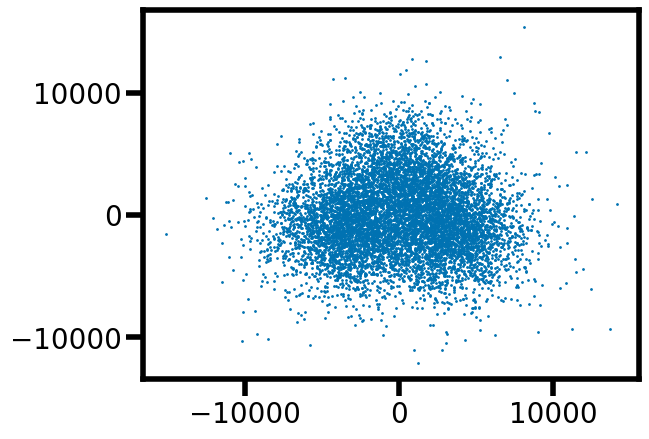

In [42]:
data_directory = "/mnt/home/levans/ceph/cryo_reweighting_examples/latent_example"
zdim=2
log_likelihood = -1*jnp.load(f"{data_directory}/log_likelihood_zs_subset_{zdim}.npy").astype('float16')
zs = jnp.load(f"{data_directory}/zs_subset_{zdim}.npy").astype('float16')
# Stuff for throwing away points
#log_likelihood_orig = -1*jnp.load(f"{data_directory}/log_likelihood_zs_subset_{zdim}.npy").astype('float32')
#zs_orig = jnp.load(f"{data_directory}/zs_subset_{zdim}.npy").astype('float32')
#print(zs_orig.shape)
#print(zs_orig**2)
#print(jnp.sum(zs_orig**2, axis=1))
#zs_idx = jnp.sqrt(jnp.sum(zs_orig**2, axis=1)) < 50000
#print(zs_idx)
#zs = zs_orig[zs_idx, :]
#print(zs.shape)
#log_likelihood = log_likelihood_orig[:, zs_idx]


num_images, num_nodes = log_likelihood.shape
print(f"{num_images} images, {num_nodes} nodes")

plt.figure()
plt.scatter(zs[:, 0], zs[:, 1], s=1)
#plt.figure()
#plt.scatter(zs_orig[:, 0], zs_orig[:, 1])




# Define diagnostics shared across methods

In [43]:
@jax.jit
def grad_log_prob(weights: ArrayLike, likelihood: ArrayLike) -> Array:
    model = jnp.sum(likelihood*weights, axis=1)
    grad = jnp.mean(likelihood/model[:, jnp.newaxis], axis=0)
    return grad

@jax.jit
def grad_log_prob_reg(weights, grad, reg) -> Array:
    grad_reg = grad - 0.5*reg*grad.shape[0]*weights
    return grad_reg


@jax.jit
def compute_loss(weights: ArrayLike, likelihood: ArrayLike) -> Array:
    loss = -1*jnp.mean(jnp.log(jnp.sum(likelihood*weights, axis=1)))
    #loss = -jnp.mean(jax.scipy.special.logsumexp(a=log_likelihood, b=weights, axis=1))
    return loss

@jax.jit
def update_stats(weights: ArrayLike, likelihood: ArrayLike):
    loss = compute_loss(weights, likelihood)
    #weights_error = 0.5*(jnp.sum(true_weights**2/weights) -  1)
    #weights_error = jnp.sum((weights - true_weights)**2)
    return loss

@jax.jit
def grad_log_prob_in_log_space(weights,log_likelihood):
    #eps = 10**(-10)
    num_images, num_structures = log_likelihood.shape
    #log_likelihood_aux = jnp.where(log_likelihood, weights > 
    log_density_at_weights = jax.scipy.special.logsumexp(a=log_likelihood, b=weights, axis=1)
    aux = log_likelihood - log_density_at_weights.reshape(num_images, 1)
    grad = jnp.exp(jax.scipy.special.logsumexp(aux, axis=0) + jnp.log(1/num_images))
    return grad

@jax.jit
def set_nonzeros(weights, grad):
    eps = 10**-20
    weights = jnp.where(jnp.logical_or(weights > eps, grad > 1), weights, 0.)
    weights /= jnp.sum(weights)
    #likelihood = likelihood*idx_bool
    return weights

@jax.jit
def set_weights_likelihood(full_weights, full_likelihood, idx):
    weights = full_weights[idx]
    likelihood = full_likelihood[:, idx]
    return weights, likelihood

@jax.jit
def get_nonzeros(full_weights):
    eps = 10**(-10)
    return full_weights > eps


In [44]:
@jax.jit
def update_weights(weights: ArrayLike, grad: ArrayLike) -> Array:
    weights = weights*grad 
    return weights

@jax.jit
def update_weights_log(weights: ArrayLike, log_grad: ArrayLike) -> Array:
    log_weights = jnp.log(weights) + log_grad
    weights = jnp.exp(log_weights)
    return weights

@jax.jit
def update_weights_entropy(weights: ArrayLike, grad: ArrayLike, reg) -> Array:
    #grad_aux =  grad - (reg/jnp.log(weights.shape[0]))*(jnp.log(weights))
    grad_aux =  grad - 0.5*reg*weights.shape[0]*weights
    weights = weights*grad_aux 
    weights /= jnp.sum(weights)
    return weights

@jax.jit
def log_likelihood_to_likelihood(log_likelihood):
    # Subtracting the largest entry from each row of likelihood
    # The gradient is invariant to row scaling of likelihood, so this is valid
    # With this, we avoid working in log space for the grad and loss
    log_likelihood = log_likelihood - jnp.max(log_likelihood, 1)[:, jnp.newaxis]
    
    # NOTE: we cannot exponentiate this if previous step hasn't happened 
    likelihood = jnp.exp(log_likelihood)
    return likelihood 

def multiplicative_gradient(
    log_likelihood: ArrayLike,
    tol: Optional[float] = 1e-8,
    max_iterations: Optional[float] = 10000,
    verbose: Optional[bool]=False,
    iter_freq: Optional[int] = 100,
    reg=0.0,
    METHOD="no_reg"
):

    num_images, num_structures = log_likelihood.shape

    # Initialize Weights
    weights = (1/num_structures)*jnp.ones(num_structures)

    # Get likelihood matrix after normalizing rows
    likelihood = log_likelihood_to_likelihood(log_likelihood)

    # Iterate
    stats = {}
    stats["loss"] = []
    stats["gap"] = []
    stats["gap_alt"] = []
    stats["gap_alt_other"] = []
    stats["weights"] = []
    stats["weights_idx"] = []

    for k in range(max_iterations):
        grad = grad_log_prob(weights, likelihood)
        grad_reg = grad_log_prob_reg(weights, grad, reg)
        if METHOD == "no_reg": 
            weights = update_weights(weights, grad)
        elif METHOD == "reg":
            weights = update_weights_entropy(weights, grad, reg)
        # update per iteration stats
        loss  = update_stats(weights, likelihood)
        # Check stopping criterion: this `gap` is an upper bound on our loss compared to optimal weights
        gap = jnp.max(grad_reg) - 1
        gap_alt = jnp.sum(weights*(grad_reg - 1)**2)

        if k % iter_freq == 0: 
            if verbose:
                print(f"Number of iterations:{k}")
                print(f"Gap: {gap}") 
            stats["weights"].append(weights)
            stats["weights_idx"].append(k)
        
        stats["loss"].append(loss)
        stats["gap_alt"].append(gap_alt)
        stats["gap"].append(gap)

    stats["weights"] = jnp.stack(stats["weights"])
    stats["loss"] = jnp.stack(stats["loss"])
    stats["weights_idx"] = jnp.stack(stats["weights_idx"])
    stats["gap"] = jnp.stack(stats["gap"])
    stats["gap_alt"] = jnp.stack(stats["gap_alt"])
    return weights, stats

In [45]:
def plot_weights(zs, ensemble_weights, coords, xbounds=None, ybounds=None, vmin=None, vmax=None):
    plt.figure()
    if vmin==None or vmax==None:
        plt.scatter(zs[:, coords[0]], zs[:, coords[1]], c=ensemble_weights, s=5, cmap="inferno")
    else: 
        plt.scatter(zs[:, coords[0]], zs[:, coords[1]], c=ensemble_weights, s=5, cmap="inferno", vmin=vmin, vmax=vmax)
    
    if xbounds is not None: 
        plt.xlim(xbounds)
        plt.ylim(ybounds)
    plt.xlabel("PC 0")
    plt.ylabel(f"PC {1}")
    #plt.colorbar()
    plt.tight_layout()
    plt.savefig("test.png")

In [46]:
#nodes = jnp.linspace(0, 19, 20) + 0.5 
#
#results = {}
#
#METHOD ="no_reg"
#ensemble_weights, stats = multiplicative_gradient(log_likelihood, true_weights, max_iterations=10000, iter_freq=1, METHOD=METHOD)
#results[METHOD] = {"ensemble_weights":ensemble_weights, "stats":stats}
#
#jnp.savez(f"{data_directory}/data_long_run.npz", results=results[METHOD])

results = {}

ensemble_weights, stats = multiplicative_gradient(log_likelihood, max_iterations=1000, iter_freq=1, tol=-1, METHOD="reg", reg=1E-8) 
results = {"ensemble_weights":ensemble_weights, "stats":stats}



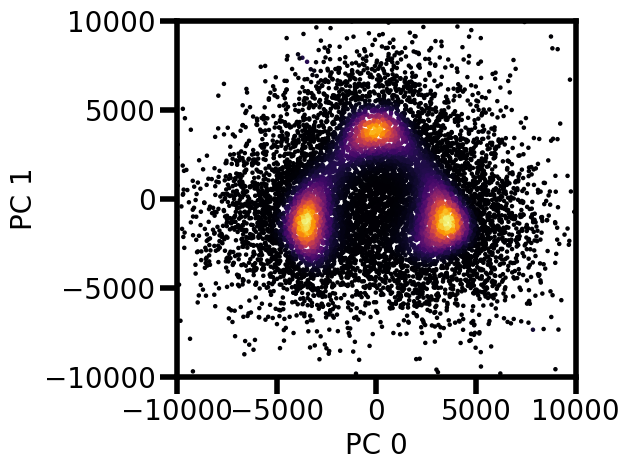

In [47]:
#vmin = jnp.amin(ensemble_weights)
#vmax = jnp.amax(ensemble_weights)

#plot_weights(zs, ensemble_weights, xbounds, ybounds)
xbounds = [-10000, 10000]
ybounds = [-10000, 10000]
weights_all = results["stats"]["weights"]
#plot_weights(zs, weights_all[, :], coords=[0,1], xbounds=xbounds, ybounds=ybounds)
plot_weights(zs, ensemble_weights, coords=[0, 1], xbounds=xbounds, ybounds=ybounds)
#plt.colorbar()

#plt.scatter(zs[5230, 0], zs[5230, 1], s=50, c='r')
import matplotlib
#plt.scatter(zs[:, -1], zs[:, -2], c=ensemble_weights, s=1, norm=matplotlib.colors.LogNorm(vmin=1E-10, vmax=1E-1), cmap='inferno')
plt.savefig(f"{fig_dir}/weight_true_max_iter.png", dpi=300)


In [48]:
#weights_unrolled = ensemble_weights.ravel()
#plt.semilogy(weights_unrolled.sort())

204


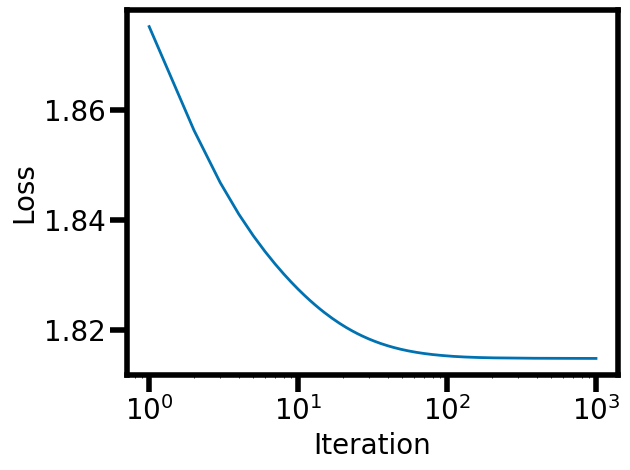

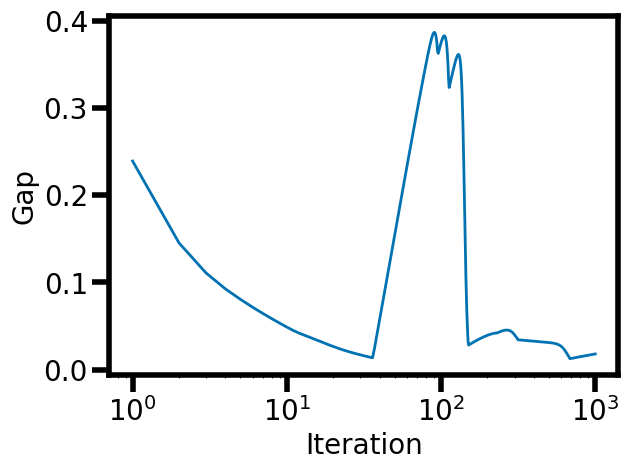

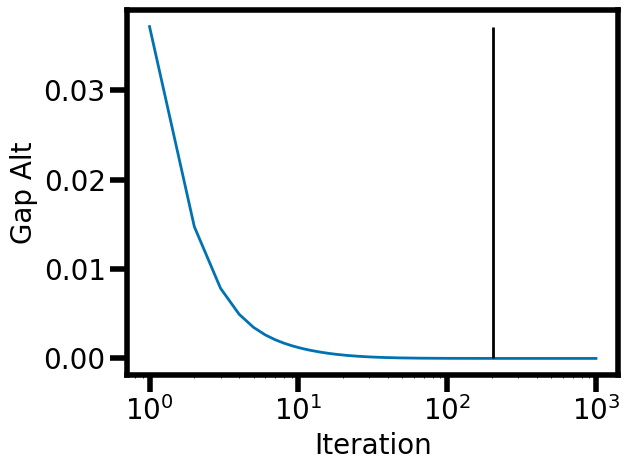

In [49]:
check_idx = 0
losses = results["stats"]["loss"]

idx = np.arange(check_idx, len(losses), 1)
plt.figure()
plt.semilogx(idx+1, losses[check_idx:], linestyle="-")
plt.ylabel("Loss")
plt.xlabel("Iteration")
plt.tight_layout()
plt.savefig(f"{fig_dir}/losses.png", dpi=300)


plt.figure()
gap = results["stats"]["gap"]
#gap_alt = results["stats"]["gap_alt"]
idx = np.arange(check_idx, len(losses), 1)
plt.semilogx(idx+1, gap[check_idx:], linestyle="-")
#plt.semilogx(idx+1, gap_alt[check_idx:], linestyle="-")
plt.ylabel("Gap")
plt.xlabel("Iteration")
plt.tight_layout()
plt.savefig(f"{fig_dir}/gap.png", dpi=300)


plt.figure()
gap_alt = results["stats"]["gap_alt"]
#gap_alt = results["stats"]["gap_alt"]
idx = np.arange(check_idx, len(losses), 1)
plt.semilogx(idx+1, gap_alt[check_idx:], linestyle="-")
#plt.semilogx(idx+1, gap_alt[check_idx:], linestyle="-")

ind = 0
while True:
    ind +=1 
    if gap_alt[ind] < 1e-6:
        print(ind)
        break


plt.vlines(ind, ymin=np.min(gap_alt), ymax=np.max(gap_alt), colors='k')
plt.ylabel("Gap Alt")
plt.xlabel("Iteration")
plt.tight_layout()
plt.savefig(f"{fig_dir}/gap_alt.png", dpi=300)







# Find the "early stopped weights":
## 1)gradient tol
## 2) cross validation

In [50]:
#data_long_run = jnp.load(f"{data_directory}/data_long_run.npz", allow_pickle=True)
#results = data_long_run["results"]
stats = results["stats"]
weights_all = stats["weights"]

# Find gradient tol

In [51]:
num_iterations = weights_all.shape[0]
tol = -jnp.log(0.99)
check_tol = True

log_likelihood = log_likelihood - jnp.max(log_likelihood, 1)[:, jnp.newaxis]
    
# NOTE: we cannot exponentiate this if previous step hasn't happened 
likelihood = jnp.exp(log_likelihood)
    
tol_idx = None
dists = []
for k in range(num_iterations):
        weights = weights_all[k, :]
        grad = grad_log_prob(weights, likelihood)
        if check_tol:
            gap = jnp.max(grad) - 1
            #print(gap)
            if gap < tol:
                tol_idx = k
                check_tol = False

print(tol_idx)

None


# Find cross validation

In [52]:
import numpy as np
np.random.seed(100)

# Compute 80-20 split
split = int(jnp.ceil(0.8*num_images))
print(split)
train_idx = np.random.choice(num_images, split, replace=False)
print(len(train_idx))
test_idx = np.setdiff1d(np.arange(num_images), train_idx)
likelihood_train = likelihood[train_idx, :].copy()
likelihood_test = likelihood[test_idx, :].copy()

# Run reweighting on the train split
results = {}
METHOD ="no_reg"
ensemble_weights, stats_train = multiplicative_gradient(likelihood_train, max_iterations=1000, iter_freq=1)
results_train = {"ensemble_weights":ensemble_weights, "stats":stats_train}
jnp.savez(f"{data_directory}/data_long_run_train.npz", results=results_train)

# Load data
data_long_run_train = jnp.load(f"{data_directory}/data_long_run_train.npz", allow_pickle=True)
results_train = data_long_run_train["results"]
stats_train = results_train.item()["stats"]
weights_all_train = stats_train["weights"]

# Compute losses on test split
num_iterations = weights_all_train.shape[0]
losses_test = []
for k in range(num_iterations):
        weights = weights_all_train[k, :]
        loss_test = compute_loss(weights, likelihood_test)
        losses_test.append(loss_test)
losses_test = jnp.stack(losses_test)

72000
72000


13


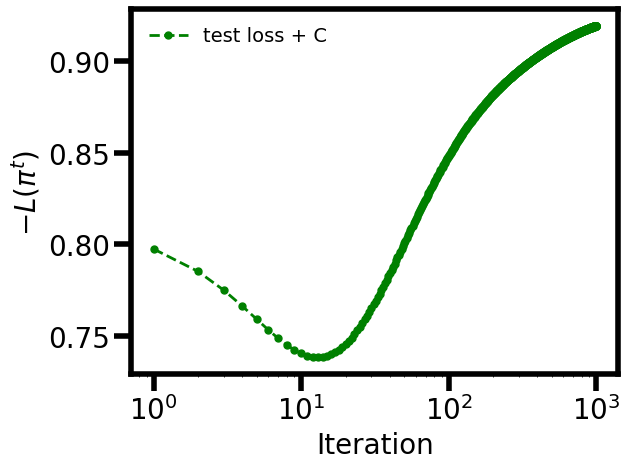

In [53]:
check_idx = 0
losses_train = stats_train["loss"]


# translate test loss to see plot better
losses_test -= losses_test[0] - losses_train[0]

idx = np.arange(check_idx, len(losses_train), 1)
#plt.semilogx(idx+1, losses_train[check_idx:], 'go--', label="train loss", markersize=10)
plt.semilogx(idx+1, losses_test[check_idx:], 'go--', label="test loss + C", markersize=5)
#plt.vlines(tol_idx, ymin=np.min(losses), ymax=np.max(losses), colors='k')
plt.ylabel(r"$-L(\pi^t)$")
plt.xlabel("Iteration")
plt.legend(fontsize=14)
#plt.xlim([10, 13])
#plt.ylim([0.7, 0.8])
plt.tight_layout()
plt.savefig(f"{fig_dir}/train_test.png", dpi=300)


k = 0
while True:
    if losses_test[k+1] > losses_test[k]:
        cross_val_idx = k + 1
        break
    else:
        k = k+1 
print(cross_val_idx)

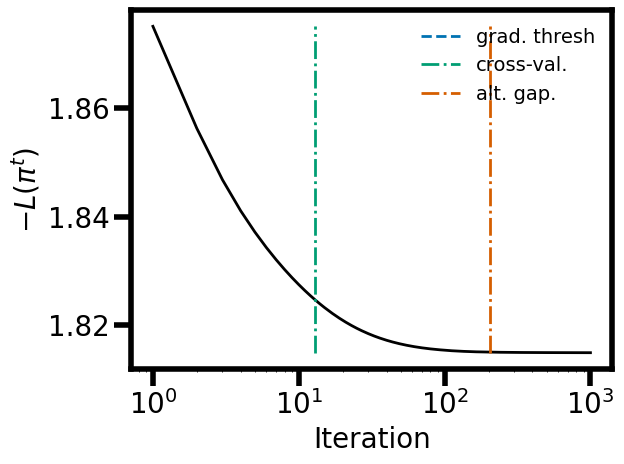

<Figure size 640x480 with 0 Axes>

In [54]:
import numpy as np
plt.figure()
plt.rcParams.update({'font.size': 12})

check_idx = 0
METHOD = "no_reg"
losses = stats["loss"]

idx = np.arange(check_idx, len(losses), 1)
plt.semilogx(idx+1, losses[check_idx:], c='k')
plt.vlines(tol_idx, ymin=np.min(losses), ymax=np.max(losses), colors='C0', linestyles="--", label="grad. thresh")
plt.vlines(cross_val_idx, ymin=np.min(losses), ymax=np.max(losses), colors='C1', linestyles="-.", label="cross-val.")
plt.vlines(ind, ymin=np.min(losses), ymax=np.max(losses), colors='C2', linestyles="-.", label="alt. gap.")
plt.ylabel(r"$-L(\pi^t)$")
plt.xlabel("Iteration")
plt.legend(fontsize=14)
plt.tight_layout()
plt.savefig(f"{fig_dir}/losses_with_stopping.png", dpi=300)

import numpy as np
plt.figure()
plt.rcParams.update({'font.size': 12})

#check_idx = 0
#METHOD = "no_reg"
#errors = stats["weights_error"]
#    
#idx = np.arange(check_idx, len(losses), 1)
#plt.semilogx(idx+1, errors[check_idx:], c='k')
##plt.ylim([np.amin(errors), errors[0]])
#plt.vlines(tol_idx, ymin=np.min(errors), ymax=np.max(errors), colors='C0', linestyles="--", label="cross-val")
#plt.vlines(cross_val_idx, ymin=np.min(errors), ymax=np.max(errors), colors='C1', linestyles="-.", label="grad. thresh.")
#plt.ylabel(r"$||\pi^{true} -\pi^t||^2$")
#plt.xlabel("Iteration")
#plt.legend(fontsize=14)
#plt.tight_layout()
##plt.savefig(f"{fig_dir}/weights_error_both_methods.png", dpi=300)
#plt.savefig(f"{fig_dir}/weights_error.png", dpi=300)

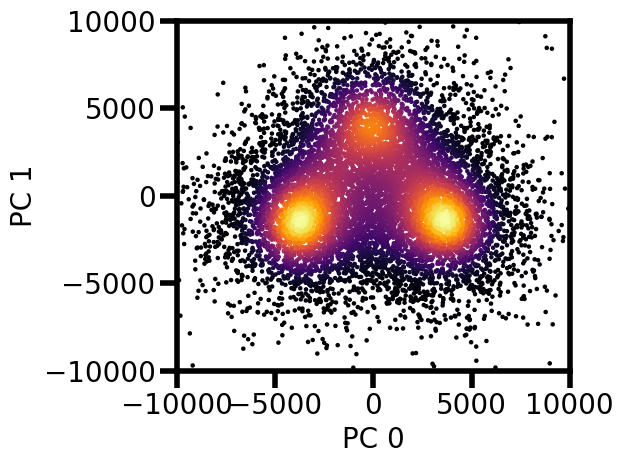

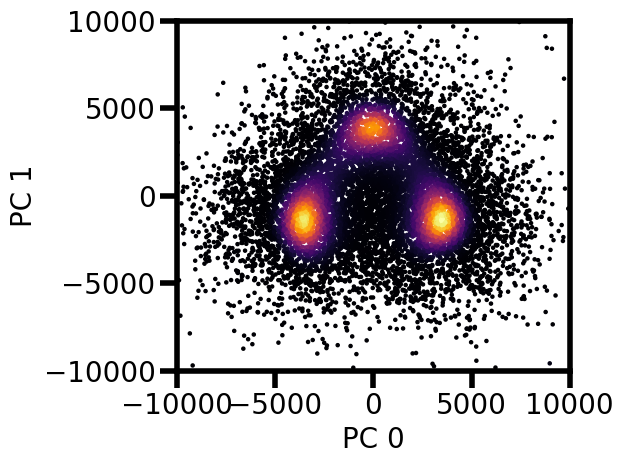

In [55]:
#plot_weights(zs, ensemble_weights, xbounds, ybounds)
xbounds = [-10000, 10000]
ybounds = [-10000, 10000]
#weights_all = results["stats"]["weights"]
#plot_weights(zs, weights_all[, :], coords=[0,1], xbounds=xbounds, ybounds=ybounds)
#plot_weights(zs, weights_all[tol_idx, :], coords=[0, 1], xbounds=xbounds, ybounds=ybounds)
#plt.colorbar()

#plt.scatter(zs[5230, 0], zs[5230, 1], s=50, c='r')
import matplotlib
#plt.scatter(zs[:, -1], zs[:, -2], c=ensemble_weights, s=1, norm=matplotlib.colors.LogNorm(vmin=1E-10, vmax=1E-1), cmap='inferno')
#plt.savefig(f"{fig_dir}/weight_grad_thresh.png", dpi=300)

plot_weights(zs, weights_all[cross_val_idx, :], coords=[0, 1], xbounds=xbounds, ybounds=ybounds)
#plt.colorbar()

#plt.scatter(zs[5230, 0], zs[5230, 1], s=50, c='r')
import matplotlib
#plt.scatter(zs[:, -1], zs[:, -2], c=ensemble_weights, s=1, norm=matplotlib.colors.LogNorm(vmin=1E-10, vmax=1E-1), cmap='inferno')
plt.savefig(f"{fig_dir}/weight_cross_val.png", dpi=300)

plot_weights(zs, weights_all[ind, :], coords=[0, 1], xbounds=xbounds, ybounds=ybounds)
#plt.colorbar()

#plt.scatter(zs[5230, 0], zs[5230, 1], s=50, c='r')
import matplotlib
#plt.scatter(zs[:, -1], zs[:, -2], c=ensemble_weights, s=1, norm=matplotlib.colors.LogNorm(vmin=1E-10, vmax=1E-1), cmap='inferno')
plt.savefig(f"{fig_dir}/weight_gap_alt.png", dpi=300)

# Save weights at different indices

In [56]:
# soft max weights
weights = weights_all[0]
plot_str = "soft_max"
plt.figure()
plt.plot(nodes, true_weights, label='weights, true', color="k")
plt.bar(nodes, weights, width=dx, label='weights, max iter.', color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.xlim([0, 20])
plt.ylabel('Probability')  
#plt.legend(fontsize=14)
plt.savefig(f"{fig_dir}/weights_{plot_str}.png", dpi=300)
plt.axis('off')
plt.savefig(f"{fig_dir}/weights_{plot_str}_no_axis.png", dpi=300)


# gradient threshold
weights = weights_all[tol_idx]
plot_str = "grad_thresh"
plt.figure()
plt.plot(nodes, true_weights, label='weights, true', color="k")
plt.bar(nodes, weights, width=dx, label='weights, max iter.', color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.xlim([0, 20])
plt.ylabel('Probability')  
#plt.legend(fontsize=14)
plt.savefig(f"{fig_dir}/weights_{plot_str}.png", dpi=300)
plt.axis('off')
plt.savefig(f"{fig_dir}/weights_{plot_str}_no_axis.png", dpi=300)

# cross validation
weights = weights_all[cross_val_idx]
plot_str = "cross_val"
plt.figure()
plt.plot(nodes, true_weights, label='weights, true', color="k")
plt.bar(nodes, weights, width=dx, label='weights, max iter.', color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.xlim([0, 20])
plt.ylabel('Probability')  
#plt.legend(fontsize=14)
plt.savefig(f"{fig_dir}/weights_{plot_str}.png", dpi=300)
plt.axis('off')
plt.savefig(f"{fig_dir}/weights_{plot_str}_no_axis.png", dpi=300)



# sort of max_iter
weights = weights_all[1000]
plot_str = "iter_1k"
plt.figure()
plt.plot(nodes, true_weights, label='weights, true', color="k")
plt.bar(nodes, weights, width=dx, label='weights, max iter.', color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.xlim([0, 20])
plt.ylabel('Probability')  
#plt.legend(fontsize=14)
plt.savefig(f"{fig_dir}/weights_{plot_str}.png", dpi=300)
plt.axis('off')
plt.savefig(f"{fig_dir}/weights_{plot_str}_no_axis.png", dpi=300)



# max_iter
weights = weights_all[-1]
plot_str = "max_iter"
plt.figure()
plt.plot(nodes, true_weights, label='weights, true', color="k")
plt.bar(nodes, weights, width=dx, label='weights, max iter.', color="C0", alpha=0.8)
plt.xlabel('dihedral angle')
plt.xlim([0, 20])
plt.ylabel('Probability')  
#plt.legend(fontsize=14)
plt.savefig(f"{fig_dir}/weights_{plot_str}.png", dpi=300)
plt.axis('off')
plt.savefig(f"{fig_dir}/weights_{plot_str}_no_axis.png", dpi=300)






NameError: name 'nodes' is not defined

<Figure size 640x480 with 0 Axes>

# Save a gif

In [ ]:
#import io
#from matplotlib.animation import FuncAnimation
#from PIL import Image
#import matplotlib as mpl
#
#def make_weights_figs(weights_all, weights_idx, nodes, p, dx, fig_dir):
#    fig= plt.figure(figsize=(10, 6))
#    frames = []
#    for idx in range(len(weights_idx)):
#        # Create plot
#        plt.clf()
#        weights = weights_all[idx, :]
#        plt.plot(nodes, p, label='True Prob', c="C0")
#        plt.bar(nodes, weights, width=dx,
#            label='EM Weights', alpha=0.8, color="C1")
#        #plt.step(nodes, counts_observed, label='Observed Counts', where="mid", color="C1")
#        plt.text(x=3, y=0.025, s=f"iteration:{weights_idx[idx]}", fontsize=20)
#        plt.ylim([0, 0.03])
#        # Save frames as images
#        buf = io.BytesIO()
#        plt.savefig(buf, format="png")
#        buf.seek(0)
#        frames.append(Image.open(buf))
#    
#        frames[0].save(
#        f"{fig_dir}/weights_path.gif",
#        save_all=True,
#        append_images=frames[1:],
#        duration=100,
#        loop=0,
#        #subrectangles=True
#    )
#
#
## collect all weights from one run
#METHOD = "no_reg"
#weights_all = results[METHOD]["stats"]["weights"] 
#weights_idx = results[METHOD]["stats"]["weights_idx"]
#make_weights_figs(weights_all, weights_idx, nodes, true_weights, dx, fig_dir)
#
#
#
#
#
#
#
#
#
#
#

: 

: 

: 

: 

: 

: 

: 

: 

# Plot first 10 unregularized weights

In [ ]:
#plt.figure() 
#plt.plot(nodes, true_weights, label='true', color="C0")
#plt.bar(nodes, jnp.ones_like(true_weights)/true_weights.shape[0], width=dx, label='EM Weights', color="C1", alpha=0.8)
#plt.xlabel('dihedral angle')
#plt.ylabel('Probability')  
#plt.legend(fontsize=10)
#plt.ylim([0, 0.03])
#plt.text(x=2.8, y=0.025, s=f"iteration:{0}", fontsize=20)
#plt.tight_layout()
#plt.savefig(f"{fig_dir}/weight_iter_{0}.png", dpi=300)
#
#for i in range(10):
#    plt.figure() 
#    plt.plot(nodes, true_weights, label='true', color="C0")
#    plt.bar(nodes, results["reverse_kl"][0]["stats"]["weights"][i+1], width=dx, label='EM Weights', color="C1", alpha=0.8)
#    plt.xlabel('dihedral angle')
#    plt.ylabel('Probability')  
#    plt.legend(fontsize=10)
#    plt.ylim([0, 0.03])
#    plt.text(x=2.8, y=0.025, s=f"iteration:{i+1}", fontsize=20)
#    plt.tight_layout()
#    plt.savefig(f"{fig_dir}/weight_iter_{i+1}.png", dpi=300)
#


: 

: 

: 

: 

: 

: 

: 

: 

In [ ]:
#plt.figure()
#plt.rcParams.update({'font.size': 12})
#
#check_idx = 1
#for i in range(num_regs):
#
#    #METHOD = "forward_kl"
#    #losses = results[METHOD][i]["stats"]["gap_alt"]
#    
#    #idx = np.arange(check_idx, len(losses), 1)
#    #plt.plot(idx, losses[check_idx:], color=colors[i], linestyle="-")
#
#    METHOD = "reverse_kl"
#    losses = results[METHOD][i]["stats"]["gap_alt"]
#    
#    idx = np.arange(check_idx, len(losses), 1)
#    plt.plot(idx, losses[check_idx:], color=colors[i], linestyle="--")
#
#plt.ylabel("gap")
#plt.xlabel("Iteration")
#plt.title("weight error of forward/rev. kl regularization")
#plt.tight_layout()
#plt.savefig(f"{fig_dir}/gappppp_both_methods.png", dpi=300)
#plt.show()

: 

: 

: 

: 

: 

: 

: 

: 